# 03 — Extracción de los cuadros 9.1, 13.1, 14.1 y 4.1
Cada familia de cuadros tiene su parser. Los valores salen como **texto crudo**: el paso 04 los
convierte a número (el punto es separador de miles y se perdería en silencio acá).
Lo que no se puede resolver queda en `problemas_extraccion.csv`; nada se inventa.

In [1]:
%run -i modulos/comun.ipynb
%run -i modulos/juzgados.ipynb
import matplotlib.pyplot as plt

RE_NUMERO = re.compile(r"^-?\d[\d.,]*%?$")
# Hueco horizontal (puntos) bajo el cual dos palabras están pegadas: una llamada a nota al pie
# deja entre -0,2 y 0,1; el espacio normal entre palabras no baja de 1,3.
HUECO_LLAMADA = 0.5
RE_GESTION = re.compile(r"^(19|20)\d{2}$")
# Líneas de nota al pie: traen números que correrían las columnas si entraran a la tabla.
RE_NOTA = re.compile(r"^\s*(FUENTE|Fuente|NOTA|Nota|ELABORACI|Elaboraci|\(\d+\)|\d+[/.]\s*[A-Za-z])")

problemas = []
complementarias = []


def anotar_problema(cuadro, pagina, motivo, linea):
    problemas.append({"cuadro_origen": cuadro, "pagina_pdf": pagina, "motivo": motivo,
                      "linea_cruda": " ".join(str(linea).split())[:300]})


def anotar_complementaria(cuadro, pagina, etiqueta, valores):
    complementarias.append({"cuadro_origen": cuadro, "pagina_pdf": pagina,
                            "etiqueta": etiqueta, "valores": " | ".join(valores)})


def guardar(df, nombre):
    df.to_csv(INTERIM / nombre, index=False, encoding="utf-8")
    print(nombre, len(df), "filas")

## Herramientas de parseo por texto (`pdftotext -layout`)

In [2]:
def es_nota(linea):
    return RE_NOTA.match(linea) is not None


def lineas_sin_notas(pagina):
    salida = []
    for l in lineas_utiles(pagina):
        if not es_nota(l):
            salida.append(l)
    return salida


def partir(linea):
    # (etiqueta, valores): los valores son los tokens numéricos del final, separados por 2+ espacios.
    toks = re.split(r"\s{2,}", linea.strip())
    valores = []
    while len(toks) > 0 and RE_NUMERO.match(toks[-1]):
        valores.insert(0, toks.pop())
    etiqueta = " ".join(" ".join(toks).split())
    return etiqueta, valores


def posiciones(linea):
    # Números de la línea con su rango de columnas [inicio, fin). Un dígito pegado a una
    # palabra ("Yapacani1") es una llamada a nota al pie, no un valor.
    salida = []
    for m in re.finditer(r"(?<![A-Za-zÁÉÍÓÚÑáéíóúñ])-?\d[\d.,]*%?", linea):
        salida.append((m.group(0), m.start(), m.end()))
    return salida


def limites_columnas(lineas, n_esperado=None):
    # Dos números que se solapan horizontalmente están en la misma columna.
    rangos = []
    for linea in lineas:
        for tok, ini, fin in posiciones(linea):
            rangos.append((ini, fin))
    columnas = agrupar_por_x(rangos)
    if n_esperado is None or len(columnas) == n_esperado:
        return columnas, True
    # Si no da el número esperado (columna a veces centrada, a veces a la derecha),
    # se usa la envolvente de las filas completas.
    envolvente = []
    for i in range(n_esperado):
        envolvente.append([10**6, -1])
    completas = 0
    for linea in lineas:
        pos = posiciones(linea)
        if len(pos) != n_esperado:
            continue
        completas = completas + 1
        for i in range(n_esperado):
            envolvente[i][0] = min(envolvente[i][0], pos[i][1])
            envolvente[i][1] = max(envolvente[i][1], pos[i][2])
    if completas > 0:
        return envolvente, True
    return columnas, False


def columna_con_mas_solape(ini, fin, limites):
    mejor = None
    mejor_solape = 0
    for i in range(len(limites)):
        solape = min(fin, limites[i][1]) - max(ini, limites[i][0])
        if solape > mejor_solape:
            mejor = i
            mejor_solape = solape
    return mejor


def asignar_por_posicion(linea, limites):
    # Cada número va a la columna con la que más se solapa; las vacías quedan None.
    fila = [None] * len(limites)
    conflictos = []
    for tok, ini, fin in posiciones(linea):
        i = columna_con_mas_solape(ini, fin, limites)
        if i is None or fila[i] is not None:
            conflictos.append(tok)
        else:
            fila[i] = tok
    return fila, conflictos


def etiqueta_previa(linea):
    pos = posiciones(linea)
    if len(pos) == 0:
        return linea
    return linea[:pos[0][1]]


# Filas analíticas (variaciones, porcentajes...) que no son datos de la serie.
PREFIJOS_COMPLEMENTARIOS = ["VARIACIÓN", "VARIACION", "TASA DE VARIACIÓN", "MEDIA DE CAUSAS", "JUZGADOS",
                            "CANTIDAD DE JUZGADOS", "RELACIÓN PORCENTUAL", "PORCENTAJE"]


def es_complementaria(etiqueta):
    e = etiqueta.upper().strip()
    for p in PREFIJOS_COMPLEMENTARIOS:
        if e.startswith(p):
            return True
    return False


def nombres_con_extras(cols, n_valores, cuadro, pag, linea):
    # El PDF agrega columnas sin rótulo en varios cuadros: se conservan numeradas, sin bautizarlas.
    nombres = list(cols)
    extra = n_valores - len(cols)
    for i in range(extra):
        nombres.append("col_sin_rotulo_" + str(i + 1))
    if extra > 0:
        anotar_problema(cuadro, pag, str(extra) + " columna(s) sin rótulo en el encabezado", linea)
    return nombres


pags = paginas()
INTERIM.mkdir(parents=True, exist_ok=True)

## 9.1 — Movimiento de causas (una página por cuadro)

In [3]:
MOV_CON_JUZGADOS = ["num_juzgados", "pendientes_inicio", "ingresadas", "atendidas", "resueltas",
                    "pendientes_fin", "pct_resueltas", "pct_pendientes", "promedio_por_juzgado"]
MOV_BASE = ["pendientes_inicio", "ingresadas", "atendidas", "resueltas", "pendientes_fin",
            "pct_resueltas", "pct_pendientes"]
# cuadro: (página, ámbito, qué es cada fila, columnas)
MOVIMIENTO = {
    "9.1.1": (673, "capital", "materia", MOV_CON_JUZGADOS),
    "9.1.3": (680, "capital", "ciudad", MOV_CON_JUZGADOS),
    "9.1.5": (687, "provincia", "materia", MOV_BASE),
    "9.1.7": (694, "provincia", "departamento", MOV_BASE),
    "9.1.9": (701, "nacional", "materia", MOV_BASE),
    "9.1.11": (708, "nacional", "departamento", MOV_BASE),
}

filas = []
for cuadro in MOVIMIENTO:
    pag, ambito, eje, cols = MOVIMIENTO[cuadro]
    for linea in lineas_utiles(pags[pag - 1]):
        etiqueta, valores = partir(linea)
        if len(valores) == 0 or etiqueta == "":
            continue
        if es_complementaria(etiqueta):
            anotar_complementaria(cuadro, pag, etiqueta, valores)
            continue
        if len(valores) < len(cols):
            anotar_problema(cuadro, pag, "fila con " + str(len(valores)) + " valores, se esperaban " + str(len(cols)), linea)
            continue
        nombres = nombres_con_extras(cols, len(valores), cuadro, pag, linea)
        fila = {"cuadro_origen": cuadro, "pagina_pdf": pag, "ambito": ambito, "eje": eje, "etiqueta_fila": etiqueta}
        for i in range(len(nombres)):
            fila[nombres[i]] = valores[i]
        filas.append(fila)
mov = pd.DataFrame(filas)
guardar(mov, "crudo_9_1_movimiento.csv")
mov.head()

crudo_9_1_movimiento.csv 78 filas


,cuadro_origen,pagina_pdf,ambito,eje,etiqueta_fila,num_juzgados,pendientes_inicio,ingresadas,atendidas,resueltas,pendientes_fin,pct_resueltas,pct_pendientes,promedio_por_juzgado,col_sin_rotulo_1
0,9.1.1,673,capital,materia,PÚBLICO CIVIL Y COMERCIAL,163,29.688,66.140,95.828,67.788,28.040,"70,7%","29,3%",406,NaN
1,9.1.1,673,capital,materia,PÚBLICO DE FAMILIA,106,24.149,50.600,74.749,52.523,22.226,"70,3%","29,7%",477,NaN
2,9.1.1,673,capital,materia,PÚBLICO NIÑEZ Y ADOLESCENCIA,26,3.846,8.549,12.395,8.368,4.027,"67,5%","32,5%",329,NaN
3,9.1.1,673,capital,materia,PARTIDO DE TRABAJO Y SEGURIDAD SOCIAL,51,23.611,21.382,44.992,20.797,24.195,"46,2%","53,8%",419,NaN
4,9.1.1,673,capital,materia,PARTIDO ADMINISTRATIVO COACTIVO FISCAL Y TRIBU...,13,11.237,2.012,13.249,2.671,10.578,"20,2%","79,8%",155,NaN


## 9.1 — Causas resueltas por gestión 2019-2023 (5 años × cantidad y porcentaje)
Se asigna por posición porque hay filas huecas (en 9.1.6, Ejecución Penal tiene un solo año con dato).

In [4]:
GESTIONES = {"9.1.2": (677, "capital"), "9.1.6": (691, "provincia"), "9.1.10": (705, "nacional")}
ANIOS_GESTIONES = [2019, 2020, 2021, 2022, 2023]

filas = []
for cuadro in GESTIONES:
    pag, ambito = GESTIONES[cuadro]
    candidatas = []
    for l in lineas_sin_notas(pags[pag - 1]):
        etiqueta, valores = partir(l)
        if etiqueta and len(valores) > 0:
            candidatas.append(l)
    limites, ok = limites_columnas(candidatas, 10)
    if not ok:
        anotar_problema(cuadro, pag, "no se pudieron fijar las 10 columnas", "")
        limites = None
    for linea in candidatas:
        etiqueta, valores = partir(linea)
        if es_complementaria(etiqueta):
            anotar_complementaria(cuadro, pag, etiqueta, valores)
            continue
        if limites and len(valores) != 10:
            valores, conflictos = asignar_por_posicion(linea, limites)
            llenas = 0
            for v in valores:
                if v is not None:
                    llenas = llenas + 1
            anotar_problema(cuadro, pag, "fila hueca (" + str(llenas) + " de 10 celdas); las vacías quedan nulas", linea)
            if len(conflictos) > 0:
                anotar_problema(cuadro, pag, "token sin columna asignable: " + str(conflictos), linea)
        elif len(valores) != 10:
            anotar_complementaria(cuadro, pag, etiqueta, valores)
            continue
        for i in range(5):
            filas.append({"cuadro_origen": cuadro, "pagina_pdf": pag, "ambito": ambito, "eje": "materia",
                          "etiqueta_fila": etiqueta, "gestion": ANIOS_GESTIONES[i],
                          "resueltas": valores[i], "pct_resueltas": valores[i + 5]})
ges = pd.DataFrame(filas)
guardar(ges, "crudo_9_1_gestiones.csv")

crudo_9_1_gestiones.csv 235 filas


## 9.1 — Serie histórica desde 2007 (el orden de columnas del 9.1.4 no es el del 9.1.1)

In [5]:
HISTORICO = {
    "9.1.4": (684, "capital", ["pendientes_inicio", "ingresadas", "atendidas", "resueltas", "pendientes_fin",
                               "pct_resueltas", "num_juzgados", "promedio_por_juzgado"]),
    "9.1.8": (698, "provincia", MOV_BASE),
    "9.1.12": (712, "nacional", MOV_BASE),
}

filas = []
for cuadro in HISTORICO:
    pag, ambito, cols = HISTORICO[cuadro]
    for linea in lineas_utiles(pags[pag - 1]):
        toks = re.split(r"\s{2,}", linea.strip())
        if len(toks) == 0 or not RE_GESTION.match(toks[0]):
            etiqueta, valores = partir(linea)
            if len(valores) > 0 and etiqueta and es_complementaria(etiqueta):
                anotar_complementaria(cuadro, pag, etiqueta, valores)
            continue
        gestion = toks[0]
        resto = []
        for t in toks[1:]:
            if RE_NUMERO.match(t):
                resto.append(t)
                continue
            # En la fila 2023 del 9.1.8 hay un ">" pegado a una celda: se conserva el número.
            nums = re.findall(r"-?\d[\d.,]*%?", t)
            anotar_problema(cuadro, pag, "celda con texto no numérico: " + repr(t), linea)
            if len(nums) > 0:
                for x in nums:
                    resto.append(x)
            else:
                resto.append(None)
        if len(resto) < len(cols):
            anotar_problema(cuadro, pag, "fila con " + str(len(resto)) + " valores, se esperaban " + str(len(cols)), linea)
            continue
        nombres = nombres_con_extras(cols, len(resto), cuadro, pag, linea)
        fila = {"cuadro_origen": cuadro, "pagina_pdf": pag, "ambito": ambito, "gestion": gestion}
        for i in range(len(nombres)):
            fila[nombres[i]] = resto[i]
        filas.append(fila)
his = pd.DataFrame(filas)
guardar(his, "crudo_9_1_historico.csv")

crudo_9_1_historico.csv 51 filas


## 13.1 — Autoridad sumariante (procesos disciplinarios)
En 13.1.2 y 13.1.3 se usa el nivel inferior del encabezado (amonestación, multa, suspensión,
destitución). Un rótulo partido en dos líneas se reconstruye con los fragmentos de alrededor.

In [6]:
SUMARIANTE = {
    "13.1.1": (737, "distrito", ["pendientes_inicio", "recibidas", "atendidas",
                                 "resoluciones_primera_instancia", "rechazadas", "en_tramite"]),
    "13.1.2": (738, "distrito", ["amonestacion", "multa", "suspension", "destitucion", "total_sanciones"]),
    "13.1.3": (739, "ente", ["amonestacion", "multa", "suspension", "destitucion", "total_sanciones"]),
}

filas = []
for cuadro in SUMARIANTE:
    pag, eje, cols = SUMARIANTE[cuadro]
    todas = lineas_sin_notas(pags[pag - 1])
    completas = []
    for l in todas:
        etiqueta, valores = partir(l)
        completas.append(len(valores) > 0 and len(valores) == len(cols))
    fragmentos = []
    empezo = False
    for i in range(len(todas)):
        linea = todas[i]
        etiqueta, valores = partir(linea)
        if not completas[i]:
            if empezo and etiqueta and len(valores) == 0:
                fragmentos.append(etiqueta)
            continue
        empezo = True
        if not etiqueta:
            cola = ""
            if i + 1 < len(todas) and not completas[i + 1]:
                cola = todas[i + 1]
            etiqueta = " ".join(fragmentos + [" ".join(cola.split())]).strip()
            if not etiqueta:
                anotar_problema(cuadro, pag, "fila sin rótulo recuperable", linea)
                continue
            anotar_problema(cuadro, pag, "rótulo partido en varias líneas, reconstruido como " + repr(etiqueta), linea)
        fragmentos = []
        fila = {"cuadro_origen": cuadro, "pagina_pdf": pag, "eje": eje, "etiqueta_fila": etiqueta}
        for j in range(min(len(cols), len(valores))):
            fila[cols[j]] = valores[j]
        filas.append(fila)
sum_ = pd.DataFrame(filas)
guardar(sum_, "crudo_13_1_sumariante.csv")

crudo_13_1_sumariante.csv 27 filas


## 14.1 — Personal: ítems y remuneración por distrito, ente y género
Por posición, porque hay celdas vacías. En 14.1.1 el distrito es una celda combinada centrada
en el bloque: se asigna a todas las filas hasta el SUB TOTAL que cierra el bloque.

In [7]:
PERSONAL_COLS = ["items_mujer", "items_varon", "items_acefalias", "items_total",
                 "remun_mujer", "remun_varon", "remun_acefalias", "remun_total"]
PERSONAL = {
    "14.1.1": ([743, 744], ["distrito", "ente"]),
    "14.1.2": ([745], ["ente"]),
    "14.1.3": ([746], ["distrito"]),
}
# La página 746 trae debajo del 14.1.3 una segunda tabla sin número; se extrae aparte.
CORTE_SEGUNDA_TABLA = "RELACIÓN DE PERSONAL JURISDICCIONAL"
JURISDICCIONAL_COLS = ["items", "items_pct", "remuneracion", "remuneracion_pct"]


def indice_de_corte(lineas):
    for i in range(len(lineas)):
        if CORTE_SEGUNDA_TABLA in lineas[i]:
            return i
    return None


def cerrar_bloque(bloque, distrito):
    for f in bloque:
        f["distrito"] = distrito
        f["distrito_derivado_del_bloque"] = True


filas = []
for cuadro in PERSONAL:
    paginas_cuadro, ejes = PERSONAL[cuadro]
    for pag in paginas_cuadro:
        todas = lineas_sin_notas(pags[pag - 1])
        corte = indice_de_corte(todas)
        if corte is not None:
            todas = todas[:corte]
        es_dato = []
        lineas = []
        for l in todas:
            es_dato.append(len(posiciones(l)) >= 3)
            if len(posiciones(l)) >= 3:
                lineas.append(l)
        limites, ok = limites_columnas(lineas, len(PERSONAL_COLS))
        if not ok:
            anotar_problema(cuadro, pag, "se detectaron " + str(len(limites)) + " columnas, se esperaban " + str(len(PERSONAL_COLS)), "")
        if len(limites) == 0:
            anotar_problema(cuadro, pag, "no se pudieron deducir límites de columna", "")
            continue

        bloque = []
        distrito_bloque = None
        fragmentos = []
        vista_primera_fila = False
        for i in range(len(todas)):
            linea = todas[i]
            if not es_dato[i]:
                texto = " ".join(linea.split())
                if vista_primera_fila:
                    # Una línea en mayúsculas sin números es el distrito del bloque, no un fragmento.
                    if len(ejes) == 2 and texto.upper() == texto and len(texto) > 3:
                        distrito_bloque = texto
                    else:
                        fragmentos.append(texto)
                continue
            vista_primera_fila = True
            valores, conflictos = asignar_por_posicion(linea, limites)
            if len(conflictos) > 0:
                anotar_problema(cuadro, pag, "token sin columna asignable: " + str(conflictos), linea)
            rotulos = []
            for t in re.split(r"\s{2,}", etiqueta_previa(linea).strip()):
                if t.strip():
                    rotulos.append(" ".join(t.split()))
            if len(rotulos) == 0:
                cola = ""
                if i + 1 < len(todas) and not es_dato[i + 1]:
                    cola = todas[i + 1]
                reconstruido = " ".join(fragmentos + [" ".join(cola.split())]).strip()
                if not reconstruido:
                    anotar_problema(cuadro, pag, "fila sin rótulo recuperable", linea)
                    continue
                rotulos = [reconstruido]
                anotar_problema(cuadro, pag, "rótulo partido en varias líneas, reconstruido como " + repr(reconstruido), linea)
            fragmentos = []

            fila = {"cuadro_origen": cuadro, "pagina_pdf": pag}
            ente = None
            if len(ejes) == 2:
                if len(rotulos) >= 2:
                    distrito_bloque = rotulos[0]
                    ente = " ".join(rotulos[1:])
                else:
                    ente = rotulos[0]
                fila["distrito"] = None
                fila["ente"] = ente
            else:
                fila[ejes[0]] = " ".join(rotulos)
            for j in range(min(len(PERSONAL_COLS), len(valores))):
                fila[PERSONAL_COLS[j]] = valores[j]
            bloque.append(fila)

            if len(ejes) == 2 and ente and ente.upper().startswith("SUB TOTAL"):
                cerrar_bloque(bloque, distrito_bloque)
                filas.extend(bloque)
                bloque = []
                distrito_bloque = None
        if len(bloque) > 0:
            if len(ejes) == 2:
                cerrar_bloque(bloque, distrito_bloque)
                anotar_problema(cuadro, pag, "bloque sin SUB TOTAL de cierre; distrito asignado por arrastre", "")
            filas.extend(bloque)
per = pd.DataFrame(filas)
guardar(per, "crudo_14_1_personal.csv")

crudo_14_1_personal.csv 85 filas


In [8]:
filas = []
pag = 746
lineas = lineas_sin_notas(pags[pag - 1])
corte = indice_de_corte(lineas)
if corte is None:
    anotar_problema("sin_numero_p746", pag, "no se encontró el encabezado de la segunda tabla", "")
else:
    for linea in lineas[corte:]:
        etiqueta, valores = partir(linea)
        if not etiqueta or len(valores) != len(JURISDICCIONAL_COLS):
            continue
        fila = {"cuadro_origen": "s/n (p. 746)", "pagina_pdf": pag,
                "titulo_tabla": "RELACIÓN DE PERSONAL JURISDICCIONAL Y ADMINISTRATIVO EN EL ÓRGANO JUDICIAL",
                "personal": etiqueta}
        for j in range(len(JURISDICCIONAL_COLS)):
            fila[JURISDICCIONAL_COLS[j]] = valores[j]
        filas.append(fila)
jur = pd.DataFrame(filas)
guardar(jur, "crudo_p746_jurisdiccional_administrativo.csv")
jur

crudo_p746_jurisdiccional_administrativo.csv 3 filas


,cuadro_origen,pagina_pdf,titulo_tabla,personal,items,items_pct,remuneracion,remuneracion_pct
0,s/n (p. 746),746,RELACIÓN DE PERSONAL JURISDICCIONAL Y ADMINIST...,JURISDICCIONAL,5.758,79%,39.674.700,81%
1,s/n (p. 746),746,RELACIÓN DE PERSONAL JURISDICCIONAL Y ADMINIST...,ADMINISTRATIVO,1.569,21%,9.467.800,19%
2,s/n (p. 746),746,RELACIÓN DE PERSONAL JURISDICCIONAL Y ADMINIST...,TOTAL,7.327,100%,49.142.500,100%


## 4.1 — Número de juzgados, con coordenadas reales (`-bbox-layout`)
En la página 116 el modo `-layout` corre la fila de totales 20 caracteres y las columnas dejan de
alinearse; con coordenadas reales cierran las diez páginas. Las columnas salen como `col_NN` y
los fragmentos de encabezado que caen sobre cada una se guardan aparte: el nombre lo decide
una persona (auditoría de encabezados).

In [9]:
JUZGADOS = {
    "4.1.1": (109, "CIUDADES CAPITALES Y EL ALTO"),
    "4.1.2": (110, "CHUQUISACA"),
    "4.1.3": (111, "LA PAZ"),
    "4.1.4": (112, "COCHABAMBA"),
    "4.1.5": (113, "ORURO"),
    "4.1.6": (114, "POTOSI"),
    "4.1.7": (115, "TARIJA"),
    "4.1.8": (116, "SANTA CRUZ"),
    "4.1.9": (117, "BENI"),
    "4.1.10": (118, "PANDO"),
}


def unir_palabras(palabras):
    # Sin espacio cuando se tocan (llamada al pie de "Camiri2"), con espacio cuando no.
    texto = palabras[0][4]
    for i in range(1, len(palabras)):
        if palabras[i][0] - palabras[i - 1][2] < HUECO_LLAMADA:
            texto = texto + palabras[i][4]
        else:
            texto = texto + " " + palabras[i][4]
    return texto


def indices_de_llamada(grupo):
    # Números pegados a la palabra anterior: son llamadas a nota al pie, no valores.
    indices = set()
    for i in range(1, len(grupo)):
        w = grupo[i]
        if RE_NUMERO.match(w[4]) and not RE_NUMERO.match(grupo[i - 1][4]) and w[0] - grupo[i - 1][2] < HUECO_LLAMADA:
            indices.add(i)
    return indices


filas_juz = []
encabezados = []
for cuadro in JUZGADOS:
    pag, depto = JUZGADOS[cuadro]
    datos = []
    otras = []
    for grupo in filas_bbox(pag):
        texto = " ".join(w[4] for w in grupo)
        if es_ruido(texto) or es_nota(texto):
            continue
        llamadas = indices_de_llamada(grupo)
        numeros = []
        rotulos = []
        for i in range(len(grupo)):
            if RE_NUMERO.match(grupo[i][4]) and i not in llamadas:
                numeros.append(grupo[i])
            else:
                rotulos.append(grupo[i])
        # Fila de datos: todo el texto a la izquierda de todos los números.
        # Las notas al pie intercalan texto entre cifras y quedan afuera.
        if len(numeros) >= 2 and len(rotulos) > 0 and max(w[2] for w in rotulos) < min(w[0] for w in numeros):
            datos.append((grupo, numeros, rotulos))
        else:
            otras.append(grupo)
    if len(datos) == 0:
        anotar_problema(cuadro, pag, "sin filas de datos reconocibles", "")
        continue

    rangos = []
    for grupo, numeros, rotulos in datos:
        for w in numeros:
            rangos.append((w[0], w[2]))
    limites = agrupar_por_x(rangos)

    cabeceras = []
    for i in range(len(limites)):
        cabeceras.append([])
    for grupo in otras:
        for w in grupo:
            i = columna_con_mas_solape(w[0], w[2], limites)
            if i is not None:
                cabeceras[i].append(w[4])
    for i in range(len(cabeceras)):
        encabezados.append({"cuadro_origen": cuadro, "pagina_pdf": pag, "departamento": depto,
                            "columna": "col_" + str(i + 1).zfill(2),
                            "fragmentos_encabezado": " ".join(cabeceras[i])[:300]})

    # La provincia es una celda combinada centrada en su bloque: cada fila toma la etiqueta
    # de provincia más cercana en vertical.
    x_localidad = 0
    if len(datos) > 0:
        x_localidad = min(min(w[0] for w in rot) for g, n, rot in datos)
    etiquetas_bloque = []
    for grupo in otras:
        if len(grupo) == 0:
            continue
        tiene_numero = False
        for w in grupo:
            if RE_NUMERO.match(w[4]):
                tiene_numero = True
        if tiene_numero:
            continue
        if min(w[0] for w in grupo) < x_localidad - 5:
            etiquetas_bloque.append((centro_vertical(grupo[0]), unir_palabras(grupo)))

    fila_orden = 1
    for grupo, numeros, rotulos in datos:
        valores = [None] * len(limites)
        for w in numeros:
            i = columna_con_mas_solape(w[0], w[2], limites)
            if i is None or valores[i] is not None:
                anotar_problema(cuadro, pag, "token sin columna asignable: " + repr(w[4]), " ".join(x[4] for x in grupo))
            else:
                valores[i] = w[4]
        # Provincia y localidad son dos columnas de texto: se separan por hueco > 8 puntos.
        partes = []
        actual = [rotulos[0]]
        for k in range(1, len(rotulos)):
            if rotulos[k][0] - rotulos[k - 1][2] > 8:
                partes.append(actual)
                actual = [rotulos[k]]
            else:
                actual.append(rotulos[k])
        partes.append(actual)
        textos = []
        for parte in partes:
            textos.append(unir_palabras(parte))

        if len(textos) > 1:
            rotulo_1 = textos[0]
            rotulo_2 = " ".join(textos[1:])
            rotulo_1_derivado = False
        elif len(etiquetas_bloque) == 0:
            rotulo_1 = textos[0]
            rotulo_2 = None
            rotulo_1_derivado = False
        else:
            y = centro_vertical(grupo[0])
            cercana = min(etiquetas_bloque, key=lambda e: abs(e[0] - y))
            rotulo_1 = cercana[1]
            rotulo_2 = textos[0]
            rotulo_1_derivado = True

        rotulo_1 = corregir_literal_extraido(cuadro, fila_orden, rotulo_1)
        fila = {"cuadro_origen": cuadro, "pagina_pdf": pag, "departamento": depto,
                "rotulo_1": rotulo_1, "rotulo_2": rotulo_2,
                "rotulo_1_derivado_del_bloque": rotulo_1_derivado, "n_columnas": len(limites)}
        for i in range(len(valores)):
            fila["col_" + str(i + 1).zfill(2)] = valores[i]
        filas_juz.append(fila)
        fila_orden = fila_orden + 1

juz = pd.DataFrame(filas_juz)
guardar(juz, "crudo_4_1_juzgados.csv")
guardar(pd.DataFrame(encabezados), "columnas_4_1_encabezados.csv")

crudo_4_1_juzgados.csv 205 filas
columnas_4_1_encabezados.csv 130 filas


## Filas complementarias y problemas

In [10]:
guardar(pd.DataFrame(complementarias), "filas_complementarias.csv")
prob = pd.DataFrame(problemas)
guardar(prob, "problemas_extraccion.csv")
prob["motivo"].str.split(":").str[0].str.replace(r"\d+", "N", regex=True).value_counts()

filas_complementarias.csv 18 filas
problemas_extraccion.csv 69 filas


motivo
N columna(s) sin rótulo en el encabezado                                                            63
fila hueca (N de N celdas); las vacías quedan nulas                                                  1
celda con texto no numérico                                                                          1
rótulo partido en varias líneas, reconstruido como 'DIRECCION ADMINISTRATIVA FINANCIERA'             1
bloque sin SUB TOTAL de cierre; distrito asignado por arrastre                                       1
rótulo partido en varias líneas, reconstruido como 'Tribunales Departamentales de Justicia'          1
rótulo partido en varias líneas, reconstruido como 'Dirección General Administrativa Financiera'     1
Name: count, dtype: int64

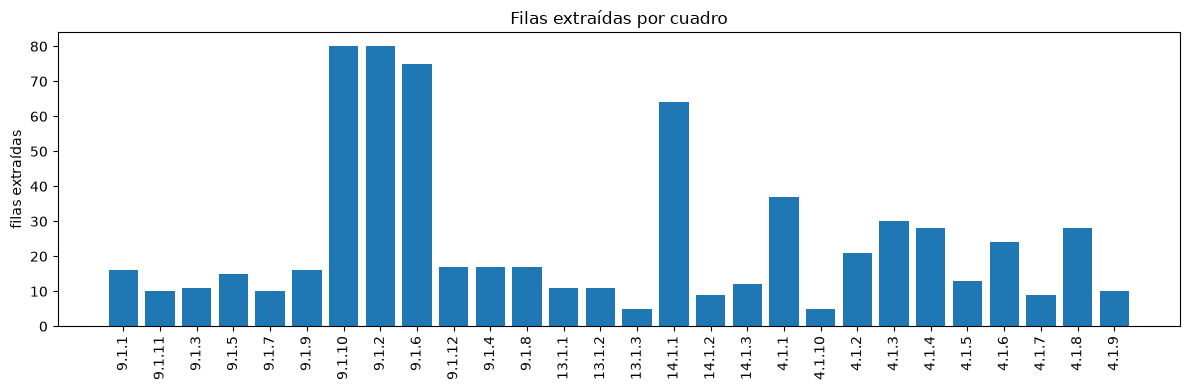

In [11]:
conteos = []
for nombre, df in [("9.1 movimiento", mov), ("9.1 gestiones", ges), ("9.1 histórico", his),
                   ("13.1 sumariante", sum_), ("14.1 personal", per), ("4.1 juzgados", juz)]:
    for cuadro, n in df.groupby("cuadro_origen").size().items():
        conteos.append((cuadro, n))
plt.figure(figsize=(12, 4))
plt.bar([c for c, n in conteos], [n for c, n in conteos], color="tab:blue")
plt.xticks(rotation=90)
plt.ylabel("filas extraídas")
plt.title("Filas extraídas por cuadro")
plt.tight_layout()
plt.show()